全连接神经网络的形状推理规则

- 矩阵相乘形状变化规则：全连接层传递数据时，通过行乘列的矩阵相乘完成维度压缩，输入维度会匹配当前层神经元个数，最终输出维度等于当前层设置的神经元数量。
- 实际案例演示：输入数据为1行4列时，经过第一层4输入4输出、第二层4输入5输出、第三层5输入6输出的全连接层后，最终输出形状为1行6列。
- 全连接层参数匹配规则：当前全连接层的输入特征数，固定等于上一层全连接层的输出特征数，输出特征数可由开发者自行定义。

全连接神经网络的PyTorch代码构建流程

- 基础导包与类定义：从torch库导入nn模块，自定义神经网络类需要继承nn.Module基类，该基类是所有PyTorch神经网络的基础父类，自带参数初始化逻辑。
- 必须实现的两个函数：需要实现`__init__`初始化函数和`forward`前向传播函数，`__init__`负责搭建网络结构，`forward`负责完成数据传递并输出结果。
- 使用Sequential时序容器：使用`nn.Sequential`时序容器按顺序保存多层全连接网络，无需手动逐层级传递数据，降低代码编写复杂度。
- 模型调用流程：先实例化自定义神经网络类，再生成符合输入形状要求的随机测试数据，最后调用forward函数得到输出结果，重点验证输出形状是否符合预期。

全连接神经网络对输入数据的要求

- 固定维度要求：全连接神经网络要求输入数据必须是二维数据，第一维是样本数量，第二维是特征数量。
- 图像数据的预处理要求：如果输入是图像数据，原始维度通常是四维（批次、通道、高度、宽度）或三维，需要通过变形操作将其压缩为二维数据才能输入全连接网络。

全连接层中权重w与偏移量b的位置和形状

- 参数的创建逻辑：开发者定义完全连接层的输入输出特征数后，PyTorch会自动在nn.Linear类内部创建权重w和偏移量b。
- 参数形状规则：权重w的形状为`(输出特征数, 输入特征数)`，总个数为输出特征数乘以输入特征数；偏移量b是一维数据，形状等于输出特征数，个数和输出特征数相等。
- 默认偏移量设置：创建nn.Linear时默认开启偏移量，bias参数默认值为True，如果设置为False则不会创建偏移量参数。

参数初始化的默认规则

- 默认初始化方法：PyTorch的nn.Linear默认使用何凯明提出的均匀分布初始化方法对w和b进行赋值，该方法配合ReLU激活函数可以让模型收敛更快。
- 自定义初始化方法：除了默认的凯明初始化，还支持手动自定义初始化，可选择常数初始化、全零初始化、正态分布初始化、均匀分布初始化等多种方式。
- 自定义初始化演示：创建输入10特征、输出5特征的nn.Linear，打印输出权重形状为(5,10)，偏移量形状为(5)，和之前推导的规则完全一致。

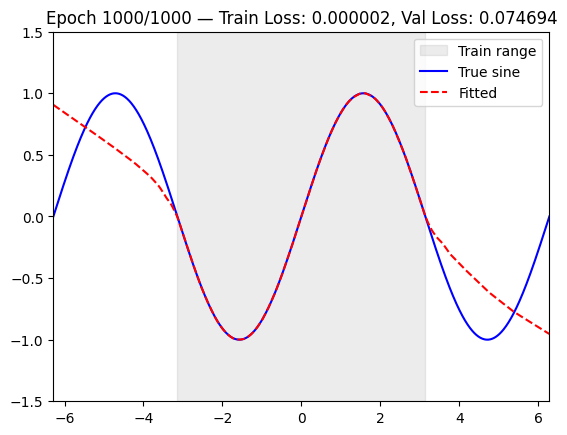

训练完成！


In [30]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 检测 GPU 是否可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 定义一个全连接神经网络，用于拟合正弦函数
class Net1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.layers(x)

# 生成数据 —— 小区间训练，大区间验证
x_train = torch.linspace(-torch.pi, torch.pi, 300).reshape(-1, 1)           # [-π, π]
y_train = torch.sin(x_train)

x_val = torch.linspace(-2 * torch.pi, 2 * torch.pi, 1000).reshape(-1, 1)    # [-2π, 2π]
y_val = torch.sin(x_val)

x_train = x_train.to(device)
y_train = y_train.to(device)
x_val = x_val.to(device)
y_val = y_val.to(device)

print(f'训练集: {len(x_train)} 个样本 (区间: [-π, π])')
print(f'验证集: {len(x_val)} 个样本 (区间: [-2π, 2π])')

# 用于绘图的数据（密集点）
x_plot = torch.linspace(-2 * torch.pi, 2 * torch.pi, 1000).reshape(-1, 1).to(device)
y_true = torch.sin(x_plot)

# 实例化网络并移到 GPU
net = Net1().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)

# 训练循环 —— 动态展示拟合过程
epochs = 1000
plot_interval = 50

plt.figure(figsize=(8, 4))

for epoch in range(epochs):
    net.train()
    pred = net(x_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % plot_interval == 0:
        net.eval()
        with torch.no_grad():
            y_pred = net(x_plot)
            train_loss = loss.item()
            val_loss = criterion(net(x_val), y_val).item()

        clear_output(wait=True)
        plt.clf()
        # 灰色背景标记训练区间
        plt.axvspan(-torch.pi, torch.pi, alpha=0.15, color='gray', label='Train range')
        plt.plot(x_plot.cpu().numpy(), y_true.cpu().numpy(), 'b-', label='True sine', linewidth=1.5)
        plt.plot(x_plot.cpu().numpy(), y_pred.cpu().numpy(), 'r--', label='Fitted', linewidth=1.5)
        plt.legend()
        plt.title(f'Epoch {epoch+1}/{epochs} — Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
        plt.xlim(-2 * torch.pi, 2 * torch.pi)
        plt.ylim(-1.5, 1.5)
        plt.show()

print('训练完成！')

In [ ]:
import torch
from torch import nn


if __name__ == '__main__':
    layer = nn.Linear(10,5)
    
    print(layer.weight.shape)
    print(layer.bias.shape)
    print(layer.bias)    
    

torch.Size([5, 10])
torch.Size([5])
Parameter containing:
tensor([-0.1826,  0.0302,  0.1674,  0.2874,  0.1176], requires_grad=True)


数据集预处理与批次加载

- 归一化操作：原始图片像素值范围是0-255，数值过大，需要进行归一化；使用transforms的ToTensor方法可以自动完成三个操作：转换为张量、将HWC格式转为CHW格式、将像素值压缩到0-1之间。
- DataLoader作用：6万张图片无法一次性全部加载到内存中训练，会导致机器死机，需要用DataLoader按小批次分批加载数据，每次给模型传入指定数量的图片。
- 核心参数说明：batch size指定每次加载的图片数量，例如6万张图片设置batch size为6000，总共需要加载10次；shuffle参数需要设置为True打乱数据顺序，如果不打乱，每次加载的都是同一类数据，模型训练会出错。
- 输出形状验证：加载完成后每张图片的形状为NCHW，N是批次大小，C是通道数，H是高度，W是宽度，标签形状和批次大小一致，每个图片对应一个标签。
- 不均匀批次处理：如果总数据量无法被batch size整除，最后一个批次的数据量会小于指定的batch size，不需要额外补数据，直接按不足的数量训练即可，不需要把batch size写死。

In [33]:
from torchvision import datasets



if __name__ == '__main__':

    train_data = datasets.MNIST(root=r'D:\Medicaldata',train= True,download=True)
    print(train_data)
    test_data = datasets.MNIST(root=r'D:\Medicaldata',train= False,download=True)
    print(test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: D:\Medicaldata
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: D:\Medicaldata
    Split: Test


Using device: cuda
训练集: 60000 张, 测试集: 10000 张
Epoch [1/5]  Loss: 0.1320  Test Acc: 0.9854 (9854/10000)
Epoch [2/5]  Loss: 0.0432  Test Acc: 0.9869 (9869/10000)
Epoch [3/5]  Loss: 0.0288  Test Acc: 0.9903 (9903/10000)
Epoch [4/5]  Loss: 0.0207  Test Acc: 0.9898 (9898/10000)
Epoch [5/5]  Loss: 0.0173  Test Acc: 0.9886 (9886/10000)


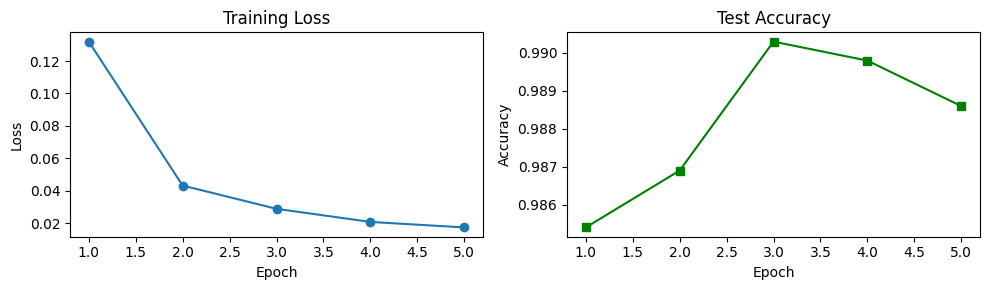

最终测试准确率: 98.86%


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ---------- 1. 数据加载 ----------
transform = transforms.Compose([
    transforms.ToTensor(),                     # 转为 Tensor (H,W,C) -> (C,H,W)
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST 全局均值和标准差
])

train_data = datasets.MNIST(root=r'D:\Medicaldata', train=True,  transform=transform, download=False)
test_data  = datasets.MNIST(root=r'D:\Medicaldata', train=False, transform=transform, download=False)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f'训练集: {len(train_data)} 张, 测试集: {len(test_data)} 张')

# ---------- 2. 定义 CNN 模型 ----------
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                                # 28x28 -> 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(2),                                # 14x14 -> 7x7
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),   # 10 个数字类别
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------- 3. 训练 ----------
epochs = 5
train_losses, test_accs = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # 测试
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
    acc = correct / len(test_data)
    test_accs.append(acc)

    print(f'Epoch [{epoch+1}/{epochs}]  Loss: {avg_loss:.4f}  Test Acc: {acc:.4f} ({correct}/{len(test_data)})')

# ---------- 4. 可视化 ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(range(1, epochs+1), train_losses, 'o-')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')

ax2.plot(range(1, epochs+1), test_accs, 's-', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy')
plt.tight_layout()
plt.show()

print(f'最终测试准确率: {test_accs[-1]*100:.2f}%')